# F1 next lap time predictor (LSTM)

In [1]:
import copy
import random
import joblib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset

In [4]:
SEED = 42
def set_seed(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
set_seed()

# Main
BATCH_SIZE = 16
MAX_EPOCHS = 80
PATIENCE = 8
VAL_FRACTION = 0.10 # leave out 10% of training for validation -> will make lower when we import 2018 - 2021

device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

print(device)


mps


### Load Data

In [5]:
data = pd.read_csv("../data/Cleaned_data2022-2025.csv")
data = data.sort_values(["Year", "Circuit", "Driver", "LapNumber"]).reset_index(drop=True)
print(data.shape)
data.head()

(89164, 21)


,Driver,Circuit,Year,LapNumber,LapsRemaining,Compound,TyreLife,TrackStatusSimple,Position,AirTemp,...,Pressure,TrackTemp,WindDirection,WindSpeed,Stint,Rainfall,InLap,OutLap,LapTimeSeconds,TargetLapTime
0,ALB,Austin,2022,1.0,55.0,MEDIUM,1.0,2,9.0,28.9,...,991.5,34.6,92,3.9,1.0,False,0,0,109.136,105.350
1,ALB,Austin,2022,2.0,54.0,MEDIUM,2.0,1,10.0,28.9,...,991.7,34.6,112,4.3,1.0,False,0,0,105.350,104.781
2,ALB,Austin,2022,3.0,53.0,MEDIUM,3.0,1,10.0,28.9,...,991.5,34.7,105,4.5,1.0,False,0,0,104.781,105.143
3,ALB,Austin,2022,4.0,52.0,MEDIUM,4.0,1,11.0,29.0,...,991.5,34.7,106,5.8,1.0,False,0,0,105.143,106.242
4,ALB,Austin,2022,5.0,51.0,MEDIUM,5.0,1,12.0,29.0,...,991.5,34.6,103,7.0,1.0,False,0,0,106.242,104.688


### Features

In [6]:
cat_features = [
    'Driver',
    'Circuit',
    'Year',
    'Compound',
    'TrackStatusSimple',
    'Rainfall',
]

num_features = [
    'LapNumber',
    'LapsRemaining',
    'TyreLife',
    'AirTemp',
    'Humidity',
    'Pressure',
    'TrackTemp',
    'WindDirection',
    'WindSpeed',
    'LapTimeSeconds',
    'Position',
    'Stint',
]
binary_features = [
    'InLap',
    'OutLap'
]
TARGET = "TargetLapTime"

In [7]:
def make_preprocessor():
    return ColumnTransformer(
        transformers = [
            ("cat",OneHotEncoder(handle_unknown="ignore",sparse_output=False),cat_features),
            ("num",StandardScaler(),num_features),
            ("binary","passthrough",binary_features)
        ],
        sparse_threshold=0 # no more .toarray()
    )

### Train / Validation / Test split

In [8]:
test_races = [
    "Shanghai",
    "Silverstone",
    "Spa-Francorchamps",
    "Spielberg",
    "Suzuka",
    "São Paulo",
    "Yas Island",
    "Zandvoort"
]

In [9]:
test_mask = (
    (data["Circuit"].isin(test_races)) &
    (data["Year"] == 2025)
)

In [10]:
trainval_data = data[~test_mask].copy()
test_data = data[test_mask].copy()

#### Validation
shouldve probably just selected some races like test but atleast we learnt new stuff

In [11]:
races = trainval_data[["Year","Circuit"]].drop_duplicates().reset_index(drop=True)

In [12]:
n_val = max(1,int(round(VAL_FRACTION * len(races)))) # num validation races
rng = np.random.default_rng(SEED)
val_races = races.iloc[rng.choice(len(races),size=n_val,replace=False)]
val_key = set(zip(val_races["Year"],val_races["Circuit"]))
is_val = np.array([k in val_key for k in zip(trainval_data["Year"], trainval_data["Circuit"])])

In [13]:
train_data = trainval_data[~is_val].copy()
val_data = trainval_data[is_val].copy()
print(f"train {len(train_data)} rows val {len(val_data)} rows test {len(test_data)} rows")


train 72070 rows val 8532 rows test 8562 rows


In [14]:
preprocessor = make_preprocessor()
preprocessor.fit(train_data.drop(columns=[TARGET]))
input_size = len(preprocessor.get_feature_names_out())

In [15]:
input_size

86

### Making Sequences 
Have decided to change what the model is predicting, now its predicting delta = TargetLapTime - LapTimeSeconds, such that predicted lap (next lap) = delta + LapTimeSeconds

Sequences (for LSTMS): One Driver, One Race

In [16]:
def make_sequences(data, preprocessor):
    sequences = []

    groups = data.groupby(
        ["Year","Circuit","Driver"], sort = False
    )
    
    for (year, circuit, driver), group in groups:
        
        group = group.sort_values("LapNumber") # just in case
        if len(group) < 2:
            continue
            
        X = preprocessor.transform(group.drop(columns=[TARGET])).astype(np.float32)

        curr = group["LapTimeSeconds"].to_numpy(dtype=np.float32) # so we don't have to undo scaling later on, this ones for absolute predictions (current laptime)
        target = group[TARGET].to_numpy(dtype=np.float32)        # same here (but this is the next laptime - what we are trying to predict)

        sequences.append({
            "year": year,
            "circuit": circuit,
            "driver": driver,
            "X": X,
            "cur": curr,
            "target": target,
            "y": target - curr,
        })
        
    return sequences

In [17]:
train_sequences = make_sequences(train_data,preprocessor)
val_sequences = make_sequences(val_data,preprocessor)
test_sequences = make_sequences(test_data,preprocessor)


### Dataset, padded batches

In [21]:
class RaceDataset(Dataset):
    
    def __init__(self, sequences):
        
        self.sequences = sequences
        
    def __len__(self):
        
        return len(self.sequences)
        
    def __getitem__(self, idx):
        
        s = self.sequences[idx]
        
        return torch.from_numpy(s["X"]), torch.from_numpy(s["y"])

def collate(batch):
    
    X, y = zip(*batch)
    
    lengths = torch.tensor([len(x) for x in X])
    
    X = pad_sequence(X, batch_first=True)
    y = pad_sequence(y, batch_first=True)
    
    mask = (torch.arange(X.shape[1])[None, :] < lengths[:, None]).float()
    
    return X, y, mask

# collate - pades some of the sequences with 0's as for example some driver end the race on lap 44 vs lap 60 (i.e dnf) so to ensure same tensor size we pad -> won't affect actual models learning though

In [22]:
train_dataset = RaceDataset(train_sequences)
val_dataset = RaceDataset(val_sequences)
test_dataset = RaceDataset(test_sequences)


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)


### Model

In [23]:
import torch.nn as nn

In [24]:
class LapTimeLSTM(nn.Module):
    def __init__(self, input_size,hidden_size=64,num_layers = 2,dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            dropout=dropout,
            batch_first = True,
        )

        self.head = nn.Sequential(
            nn.Linear(hidden_size,32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32,1),
        )

    def forward(self, x, state=None):
        out, state= self.lstm(x, state)
        return self.head(out).squeeze(-1), state

In [25]:
def init_model(input_size,lr):
    model = LapTimeLSTM(input_size = input_size)

    optimizer = torch.optim.Adam(model.parameters(),lr=lr,weight_decay=1e-5) #weight decay: my notes are somewhere, number picked by what was recommend (could try 0.1)

    loss_function = nn.HuberLoss(delta=1.0,reduction="none")

    return model, optimizer, loss_function

### Training

In [26]:
def masked_loss(pred, y, mask, loss_function):
    loss = loss_function(pred, y)
    return (loss * mask).sum() / mask.sum()

def run_epoch(model,loader,optimizer=None, loss_function=None):
    
    training = optimizer is not None
    
    model.train(training)
    
    total, count = 0.0, 0.0
    
    with torch.set_grad_enabled(training):
        for X,y, mask in loader:
            X,y, mask = X.to(device), y.to(device), mask.to(device) # moving to gpu

            pred, _ = model(X)
            loss = masked_loss(pred, y, mask, loss_function)
            
            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                
            n = mask.sum().item()
            total += loss.item() * n
            count += n
    return total / count
            



In [27]:
def train(train_loader, val_loader, input_size, max_epochs=MAX_EPOCHS, patience = PATIENCE, lr=1e-3):
    model, optimizer, loss_function = init_model(input_size,lr)
    model = model.to(device)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3) # lowers lr when traiing stops improving, patience is how many epochs you wait

    history = {"train": [], "val": []}
    best_val, best_state, bad_epochs = float("inf"), None, 0

    for epoch in range(1, max_epochs + 1):
        tr = run_epoch(model,train_loader,optimizer,loss_function)
        va = run_epoch(model,val_loader, loss_function=loss_function)

        scheduler.step(va)
        history["train"].append(tr)
        history["val"].append(va)

        # early stopping
        if va < best_val - 1e-4:
            best_val, bad_epochs = va, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            bad_epochs += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f"epoch {epoch:3d} | train {tr:.4f} | val {va:.4f}")
        if bad_epochs >= patience:
            print(f"early stop at epoch {epoch} (best val {best_val:.4f})")
            break


    model.load_state_dict(best_state)
    return model, history


In [28]:
model, history = train(train_loader, val_loader, input_size)

epoch   1 | train 2.8888 | val 2.3701
epoch   5 | train 2.0778 | val 2.5254
epoch  10 | train 1.8648 | val 2.6485
early stop at epoch 11 (best val 2.3123)


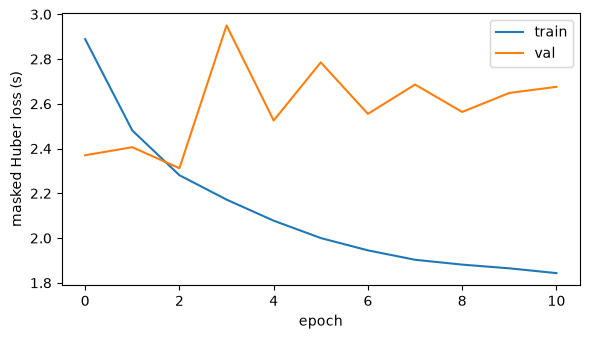

In [29]:
plt.figure(figsize=(6, 3.5))
plt.plot(history["train"], label="train")
plt.plot(history["val"], label="val")
plt.xlabel("epoch"); plt.ylabel("masked Huber loss (s)"); plt.legend(); plt.tight_layout()
plt.show()

### Evaluation (eventually to add gru here)

In [30]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, median_absolute_error

In [31]:
@torch.no_grad()
def predict_laptimes(model,seqs):
    model.eval()
    preds = []
    for s in seqs:
        x = torch.from_numpy(s["X"])[None].to(device)
        delta, _ = model(x)
        preds.append(s["cur"] + delta[0].cpu().numpy())
    return preds

def metrics(preds, seqs, name):
           
    y_pred = np.concatenate(preds)
    y_true = np.concatenate([s["target"] for s in seqs])
    
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true,y_pred),
        "MedAE": median_absolute_error(y_true,y_pred),
        "RMSE": root_mean_squared_error(y_true,y_pred)
    }

In [32]:
pd.DataFrame([metrics(predict_laptimes(model,val_sequences),val_sequences,"LSTM")]).set_index("model")

,MAE,MedAE,RMSE
model,,,
LSTM,2.61743,0.381264,6.894472


In [33]:
print("Test Races")

# per-circuit MAE on test
test_preds = predict_laptimes(model, test_sequences)
per_circuit = {}
for s, p in zip(test_sequences, test_preds):
    per_circuit.setdefault(s["circuit"], []).append(np.abs(p - s["target"]))

pd.DataFrame({
    "LSTM MAE": {c: np.concatenate(v).mean() for c, v in per_circuit.items()},
}).round(3)

Test Races


,LSTM MAE
Shanghai,0.915
Silverstone,9.044
Spa-Francorchamps,2.629
Spielberg,1.540
Suzuka,0.810
São Paulo,2.748
Yas Island,0.852
Zandvoort,4.621


In [19]:
# SHOW
def plot_laptimes(race, driver):
    matches = [
        s for s in test_sequences
        if s["circuit"].lower() == race.lower()
        and s["driver"].lower() == driver.lower()
    ]

    if not matches:
        print(f"No sequence found for {driver} at {race}")
        return

    s = matches[0]
    p = predict_laptimes(model, [s])[0]

    plt.figure(figsize=(10, 8))

    plt.plot(s["target"], label="Actual next lap")
    plt.plot(p, label="LSTM")

    plt.title(f'{s["circuit"]} {s["year"]} - {s["driver"]}')
    plt.xlabel("Lap index")
    plt.ylabel("Lap time (s)")
    plt.legend()
    plt.tight_layout()
    plt.show()

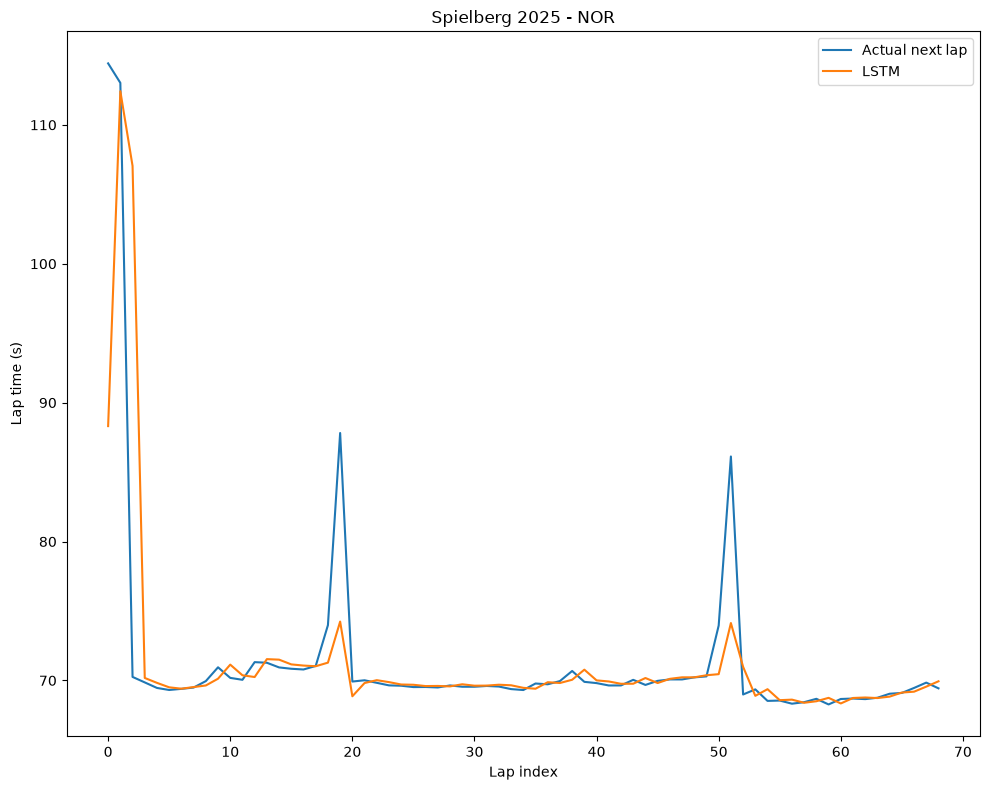

In [34]:
plot_laptimes("Spielberg","NOR")